C:\Users\崔崟\AppData\Local\Temp\ipykernel_49884\4046656054.py:42: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\崔崟\AppData\Local\Temp\ipykernel_49884\4046656054.py:42: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\崔崟\AppData\Local\Temp\ipykernel_49884\4046656054.py:42: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\崔崟\AppData\Local\Temp\ipykernel_49884\4046656054.py:42: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\崔崟\AppData\Local\Temp\ipykernel_49884\4046656054.py:42: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\崔崟\AppData\Local\Temp\ipykernel_49884\4046656054.py:42: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEO

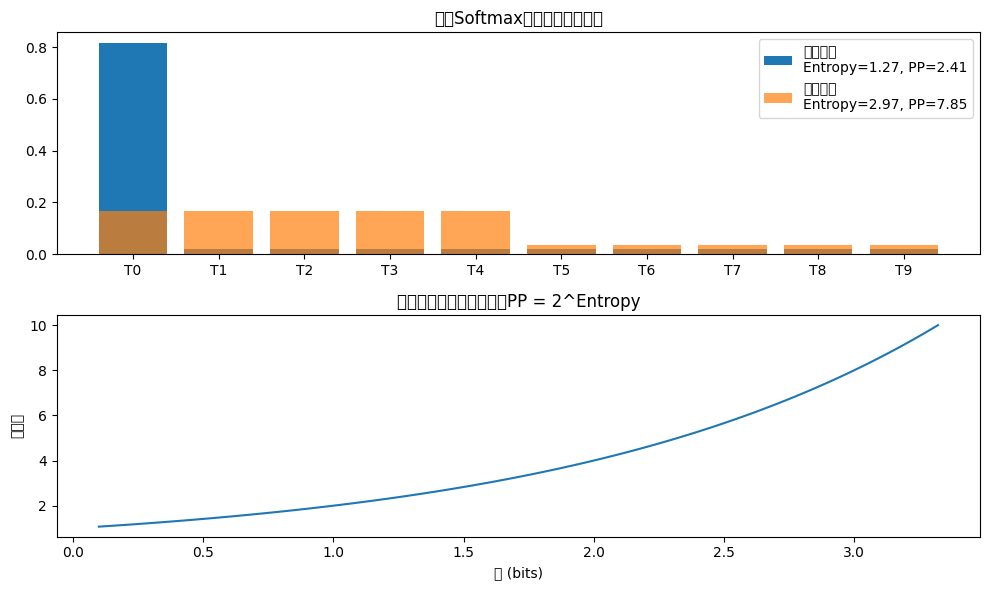

In [1]:
import matplotlib.pyplot as plt
import numpy as np

vocab_size = 10
tokens = [f"T{i}" for i in range(vocab_size)]

# 集中预测
p1 = np.array([0.8] + [0.02] * (vocab_size - 1))
p1 = p1 / p1.sum()

# 分散预测
p2 = np.array([0.2] * 5 + [0.04] * 5)
p2 = p2 / p2.sum()

def entropy(p):
    return -np.sum(p * np.log2(p + 1e-12))

def perplexity(p):
    return 2 ** entropy(p)

entropy_p1 = entropy(p1)
entropy_p2 = entropy(p2)
perplexity_p1 = perplexity(p1)
perplexity_p2 = perplexity(p2)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

# 图1：分布对比
axes[0].bar(tokens, p1, label=f"集中分布\nEntropy={entropy_p1:.2f}, PP={perplexity_p1:.2f}")
axes[0].bar(tokens, p2, alpha=0.7, label=f"分散分布\nEntropy={entropy_p2:.2f}, PP={perplexity_p2:.2f}")
axes[0].set_title("不同Softmax分布下的预测概率")
axes[0].legend()

# 图2：熵 vs 困惑度
x = np.linspace(0.1, np.log2(vocab_size), 100)
y = 2 ** x
axes[1].plot(x, y)
axes[1].set_xlabel("熵 (bits)")
axes[1].set_ylabel("困惑度")
axes[1].set_title("熵与困惑度的指数关系：PP = 2^Entropy")

plt.tight_layout()
plt.show()


In [2]:
import torch
import numpy as np
from transformers import GPT2Tokenizer, GPT2LMHeadModel

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()

@torch.no_grad()
def detect_ai_score_with_entropy_std(text):
    inputs = tokenizer(text, return_tensors="pt")
    input_ids = inputs["input_ids"]
    outputs = model(input_ids, labels=input_ids)
    logits = outputs.logits

    probs = torch.nn.functional.softmax(logits, dim=-1)
    target_ids = input_ids[:, 1:]
    probs = probs[:, :-1, :]
    token_probs = probs.gather(2, target_ids.unsqueeze(-1)).squeeze(-1)

    log_probs = torch.log(token_probs + 1e-12)
    perplexity = torch.exp(-log_probs.mean()).item()

    entropy_per_token = -torch.sum(probs * torch.log(probs + 1e-12), dim=-1)
    avg_entropy = entropy_per_token.mean().item()
    std_entropy = entropy_per_token.std().item()

    # 综合评分（引入熵标准差作为风格“自然性”的鼓励因子）
    score = 100 - (perplexity / 2 + avg_entropy * 10 - std_entropy * 5)
    score = np.clip(score, 0, 100)
    label = "Likely AI-Generated" if score > 50 else "Likely Human-Written"

    return {
        "Perplexity": round(perplexity, 2),
        "Avg Entropy": round(avg_entropy, 3),
        "Entropy Std": round(std_entropy, 3),
        "AI Likelihood Score (0-100)": round(score, 1),
        "Prediction": label
    }

# 示例调用
text = input("请输入要检测的英文文本：\n")
result = detect_ai_score_with_entropy_std(text)
for k, v in result.items():
    print(f"{k}: {v}")


c:\Users\崔崟\anaconda3\envs\py_gpu_new\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


Perplexity: 129.68
Avg Entropy: 4.532
Entropy Std: 1.962
AI Likelihood Score (0-100): 0.0
Prediction: Likely Human-Written
